# JavaScript Vulnerability Detection — Full Pipeline
### Cross-Dataset Generalization Study (Ferenc et al. + Viszkok et al.)
This notebook runs the complete pipeline we designed (all evaluations are averaged across 5 diverse random seeds for statistical robustness):
1. Load both datasets, extract repo identity, find the true repo-level overlap
2. Deduplicate overlapping functions, build **Dataset A** (44 shared metrics, all repos) and **Dataset B** (78 columns, 73-repo overlap only)
3. Correlation recap (quick sanity check — you already generated the full plots separately)
4. Imbalance-handling utilities: class weights, focal loss, SMOTE, Gaussian noise resampling
5. Evaluation metrics helper (accuracy, F1, PR-AUC, MCC)
6. Baseline classical models (XGBoost, Random Forest, Bagging) with **repo-grouped** cross-validation
7. Hybrid Stacking model (combining Deep Learning MLP with XGBoost and Random Forest)
8. In-distribution results summary
9. **Headline experiment:** train on the 73-repo pool, test on the 20 repos held out entirely
10. Secondary experiment: does adding Viszkok's extra 34 process-metric columns help, within the 73-repo overlap?
11. Final comparison table + generalization-gap plot
**Important:** put `JSVulnerabilityDataSet-1_0.csv` and `pm_uom_all_full.csv` in the same folder as this notebook before running.


In [17]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, matthews_corrcoef, classification_report
)
from xgboost import XGBClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Deep learning (stacked CNN) — requires tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM
)
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

pd.set_option("display.max_columns", 100)


## Step 1 — Load data, identify repo overlap

Every repo in Viszkok's file also appears in Ferenc's file (confirmed earlier). Ferenc has 93
total repos, Viszkok has 73 — all 73 are a subset of Ferenc's 93. That leaves **20 repos that
exist only in Ferenc's file** — these are the only genuinely unseen codebases we have, and
become our held-out generalization test set.


In [18]:
ferenc = pd.read_csv("JSVulnerabilityDataSet-1.0.csv")
viszkok = pd.read_csv("pm_uom_all_full.csv")

def get_repo(url):
    """Extract the repo identity (owner/repo) from a GitHub blob URL."""
    return url.split("/blob/")[0] if isinstance(url, str) else None

ferenc["repo"] = ferenc["full_repo_path"].apply(get_repo)
viszkok["repo"] = viszkok["full_repo_path"].apply(get_repo)

ferenc_repos = set(ferenc["repo"].dropna())
viszkok_repos = set(viszkok["repo"].dropna())

holdout_repos = ferenc_repos - viszkok_repos   # only-in-Ferenc -> true unseen test set
shared_repos  = ferenc_repos & viszkok_repos   # overlapping repos -> training pool

print(f"Ferenc repos total : {len(ferenc_repos)}")
print(f"Viszkok repos total: {len(viszkok_repos)}")
print(f"Shared repos        : {len(shared_repos)}")
print(f"Holdout repos (Ferenc-only, genuinely unseen): {len(holdout_repos)}")
assert viszkok_repos.issubset(ferenc_repos), "Expected Viszkok's repos to be a subset of Ferenc's"


Ferenc repos total : 93
Viszkok repos total: 73
Shared repos        : 73
Holdout repos (Ferenc-only, genuinely unseen): 20


In [19]:
# Function-level key for deduplication: repo + file path + line range.
# Ferenc uses line/endline, Viszkok uses start_line/end_line.
ferenc["fkey"] = (ferenc["repo"].astype(str) + "|" + ferenc["path"].astype(str) + "|" +
                   ferenc["line"].astype(str) + "|" + ferenc["endline"].astype(str))
viszkok["fkey"] = (viszkok["repo"].astype(str) + "|" + viszkok["path"].astype(str) + "|" +
                    viszkok["start_line"].astype(str) + "|" + viszkok["end_line"].astype(str))

duplicate_keys = set(ferenc["fkey"]) & set(viszkok["fkey"])
print(f"Duplicate functions found (same repo+file+line-range in both files): {len(duplicate_keys)}")

# Sanity check: for duplicated functions, do the Vuln labels agree between the two sources?
f_dup = ferenc[ferenc["fkey"].isin(duplicate_keys)][["fkey", "Vuln"]].drop_duplicates("fkey")
v_dup = viszkok[viszkok["fkey"].isin(duplicate_keys)][["fkey", "Vuln"]].drop_duplicates("fkey")
merged_check = f_dup.merge(v_dup, on="fkey", suffixes=("_ferenc", "_viszkok"))
mismatches = merged_check[merged_check["Vuln_ferenc"] != merged_check["Vuln_viszkok"]]
print(f"Label mismatches on duplicated functions: {len(mismatches)} / {len(merged_check)}")
if len(mismatches):
    print(mismatches.head().to_string())


Duplicate functions found (same repo+file+line-range in both files): 4654
Label mismatches on duplicated functions: 10 / 4654
                                                                                  fkey  Vuln_ferenc  Vuln_viszkok
12                       https://github.com/angular/angular.js|src/ng/parse.js|208|210            1             0
1182                https://github.com/electron/electron|spec/chromium-spec.js|365|373            1             0
1286   https://github.com/electron/electron|lib/browser/guest-window-manager.js|68|102            1             0
1287  https://github.com/electron/electron|lib/browser/guest-window-manager.js|105|156            1             0
1298    https://github.com/electron/electron|lib/browser/guest-window-manager.js|97|99            1             0


## Step 2 — Build Dataset A (44 shared metrics, all 93 repos)

One row per unique function. Where a function is duplicated across both files, keep Viszkok's
copy (it carries the extra columns) — for functions only in Ferenc, keep Ferenc's row.
`holdout` = True marks the 20 repos never touched by Viszkok — this is our train/test split,
done **by repo**, never by row, so a project's functions never end up split across both sides.


In [20]:
IDENTITY_COLS = ["name", "path", "longname", "full_repo_path", "line", "column",
                  "endline", "endcolumn", "start_line", "end_line", "hash", "type", "fkey"]

# Rows only in Ferenc (not duplicated in Viszkok) + all of Viszkok's rows (preferred copy)
ferenc_only_rows = ferenc[~ferenc["fkey"].isin(duplicate_keys)].copy()
dataset_A = pd.concat([ferenc_only_rows, viszkok], ignore_index=True, sort=False)

dataset_A["holdout"] = dataset_A["repo"].isin(holdout_repos)
dataset_A = dataset_A.drop(columns=[c for c in IDENTITY_COLS if c in dataset_A.columns])

# Keep only the columns that exist in BOTH original files (the 44-metric schema) + Vuln/repo/holdout
shared_metric_cols = sorted(
    (set(ferenc.columns) & set(viszkok.columns))
    - set(IDENTITY_COLS) - {"repo"}
)
keep_cols = shared_metric_cols + ["repo", "holdout"]
dataset_A = dataset_A[[c for c in keep_cols if c in dataset_A.columns]]

print("Dataset A shape:", dataset_A.shape)
print("\nRows by holdout flag:")
print(dataset_A["holdout"].value_counts())
print("\nClass balance (holdout=False, i.e. training pool):")
print(dataset_A.loc[~dataset_A["holdout"], "Vuln"].value_counts(normalize=True).round(4))
print("\nClass balance (holdout=True, i.e. the 20 unseen repos):")
print(dataset_A.loc[dataset_A["holdout"], "Vuln"].value_counts(normalize=True).round(4))


Dataset A shape: (12053, 38)

Rows by holdout flag:
holdout
False    11344
True       709
Name: count, dtype: int64

Class balance (holdout=False, i.e. training pool):
Vuln
0    0.901
1    0.099
Name: proportion, dtype: float64

Class balance (holdout=True, i.e. the 20 unseen repos):
Vuln
0    0.8166
1    0.1834
Name: proportion, dtype: float64


## Step 3 — Build Dataset B (78 columns, 73 overlapping repos only)

This is the **secondary** experiment: does adding Viszkok's extra process metrics / ESLint
warning columns help, on the subset of functions where we actually have them? It never touches
the 20 holdout repos.


In [21]:
dataset_B = viszkok.copy()
dataset_B = dataset_B.drop(columns=[c for c in IDENTITY_COLS if c in dataset_B.columns])

print("Dataset B shape:", dataset_B.shape)
print("Unique repos in Dataset B:", dataset_B["repo"].nunique(), "(should be 73)")
print("\nClass balance:")
print(dataset_B["Vuln"].value_counts(normalize=True).round(4))


Dataset B shape: (8038, 67)
Unique repos in Dataset B: 73 (should be 73)

Class balance:
Vuln
0    0.8806
1    0.1194
Name: proportion, dtype: float64


## Step 4 — Correlation recap (quick sanity check)

You already generated the full correlation plots separately — this is just a compact recap so
the notebook is self-contained. Position/identity columns were already dropped above, so this
correlation is computed only on real code-property features.


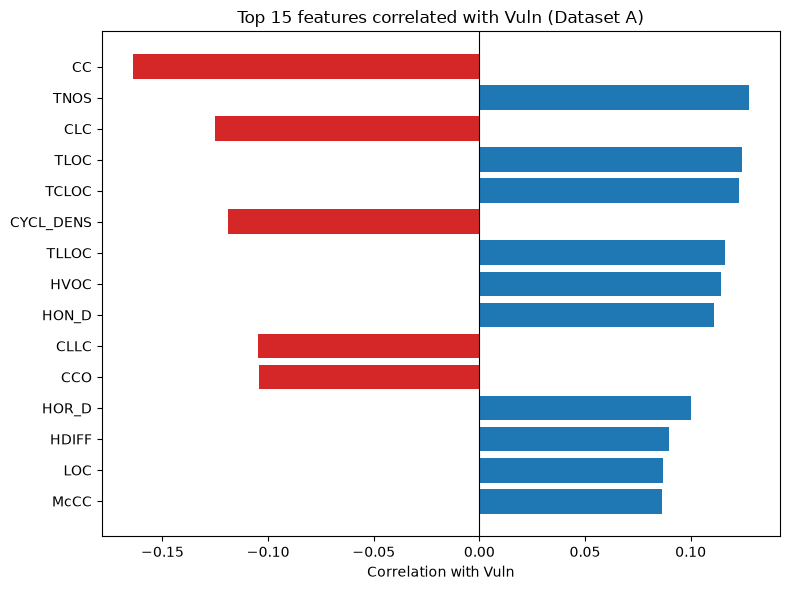

CC          -0.164153
TNOS         0.127687
CLC         -0.124930
TLOC         0.124477
TCLOC        0.123102
CYCL_DENS   -0.118996
TLLOC        0.116232
HVOC         0.114379
HON_D        0.111225
CLLC        -0.104734
CCO         -0.104520
HOR_D        0.100212
HDIFF        0.089840
LOC          0.087026
McCC         0.086493
Name: Vuln, dtype: float64


In [22]:
feature_cols_A = [c for c in dataset_A.columns if c not in ["Vuln", "repo", "holdout"]]
corr = dataset_A[feature_cols_A + ["Vuln"]].corr(numeric_only=True)["Vuln"].drop("Vuln")
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

plt.figure(figsize=(8, 6))
colors = ["#1f77b4" if val > 0 else "#d62728" for val in corr_sorted.head(15)]
plt.barh(corr_sorted.head(15).index[::-1], corr_sorted.head(15).values[::-1],
          color=colors[::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 15 features correlated with Vuln (Dataset A)")
plt.xlabel("Correlation with Vuln")
plt.tight_layout()
plt.savefig("correlation_with_vuln_A.png", dpi=150)
plt.show()

print(corr_sorted.head(15))


## Step 5 — Imbalance-handling utilities

All of these are applied **inside** each cross-validation fold, only to that fold's training
portion — never before the split, and never to the holdout set.


In [23]:
def get_class_weights(y):
    """Class weights for sklearn/XGBoost, inversely proportional to class frequency."""
    classes, counts = np.unique(y, return_counts=True)
    total = len(y)
    return {c: total / (len(classes) * cnt) for c, cnt in zip(classes, counts)}


def focal_loss(gamma=2.0, alpha=0.25):
    """Focal loss for the CNN models — down-weights easy (majority-class) examples so the
    rare vulnerable class gets more gradient signal than plain binary cross-entropy gives it."""
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=-1))
    return loss_fn


def gaussian_noise_oversample(X, y, minority_class=1, n_synthetic=None, noise_scale=0.05,
                                random_state=42):
    """Create synthetic minority samples by jittering real minority rows with small Gaussian
    noise scaled to each feature's standard deviation. Clips negative values for count-type
    features (LOC, NOS, etc. can't go below 0)."""
    rng = np.random.default_rng(random_state)
    minority_mask = y == minority_class
    X_min = X[minority_mask]
    if n_synthetic is None:
        n_synthetic = (y == (1 - minority_class)).sum() - minority_mask.sum()
        n_synthetic = max(n_synthetic, 0)
    if n_synthetic == 0:
        return X, y
    stds = X_min.std(axis=0)
    idx = rng.integers(0, len(X_min), size=n_synthetic)
    noise = rng.normal(0, noise_scale, size=(n_synthetic, X.shape[1])) * stds
    synthetic = X_min[idx] + noise
    synthetic = np.clip(synthetic, a_min=0, a_max=None)
    X_new = np.vstack([X, synthetic])
    y_new = np.concatenate([y, np.full(n_synthetic, minority_class)])
    return X_new, y_new


def smote_oversample(X, y, random_state=42):
    sm = SMOTE(random_state=random_state)
    return sm.fit_resample(X, y)


## Step 6 — Evaluation metrics helper

Accuracy/F1 alone can look good while hiding poor minority-class recall at this imbalance
level — PR-AUC and MCC are reported for every model alongside them.


In [24]:
def evaluate(y_true, y_pred, y_proba):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "pr_auc":    average_precision_score(y_true, y_proba),
        "mcc":       matthews_corrcoef(y_true, y_pred),
    }


def summarize_cv(fold_results):
    df = pd.DataFrame(fold_results)
    return df.mean().round(4), df.std().round(4)


## Step 7 — Baseline classical models (repo-grouped CV, Dataset A training pool)

`StratifiedGroupKFold` ensures no repo's functions are ever split across train and test within
a fold — the same leakage concern as the holdout split, just applied to the in-distribution
evaluation too.


In [25]:
train_A = dataset_A[~dataset_A["holdout"]].reset_index(drop=True)
holdout_A = dataset_A[dataset_A["holdout"]].reset_index(drop=True)

feature_cols_A = [c for c in dataset_A.columns if c not in ["Vuln", "repo", "holdout"]]

X_train_full = train_A[feature_cols_A].fillna(0).values
y_train_full = train_A["Vuln"].values
groups_full  = train_A["repo"].values

X_holdout = holdout_A[feature_cols_A].fillna(0).values
y_holdout = holdout_A["Vuln"].values

print("Training pool:", X_train_full.shape, " | Holdout:", X_holdout.shape)


Training pool: (11344, 35)  | Holdout: (709, 35)


In [26]:
SEEDS = [42, 123, 888, 2024, 777]

def run_baseline_cv(model_fn, X, y, groups, resample=None, n_splits=5):
    all_seed_results = []
    
    for seed in SEEDS:
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        fold_scores = []
        for tr_idx, te_idx in sgkf.split(X, y, groups):
            X_tr, y_tr = X[tr_idx], y[tr_idx]
            X_te, y_te = X[te_idx], y[te_idx]

            if resample == "smote":
                X_tr, y_tr = smote_oversample(X_tr, y_tr)
            elif resample == "gaussian":
                X_tr, y_tr = gaussian_noise_oversample(X_tr, y_tr)

            model = model_fn(y_tr, seed)
            model.fit(X_tr, y_tr)
            y_proba = model.predict_proba(X_te)[:, 1]
            y_pred = model.predict(X_te)
            fold_scores.append(evaluate(y_te, y_pred, y_proba))
        
        seed_mean, _ = summarize_cv(fold_scores)
        all_seed_results.append(seed_mean)
    
    final_mean, final_std = summarize_cv(all_seed_results)
    return final_mean, final_std, all_seed_results

def make_xgb(y_tr, seed, use_class_weight=False):
    spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1) if use_class_weight else 1.0
    return XGBClassifier(scale_pos_weight=spw, eval_metric="logloss", n_estimators=200, random_state=seed)

def make_rf(y_tr, seed, use_class_weight=False):
    return RandomForestClassifier(
        n_estimators=300, class_weight="balanced" if use_class_weight else None, random_state=seed
    )

def make_bagging(y_tr, seed, use_class_weight=False):
    return BaggingClassifier(n_estimators=100, random_state=seed)

baseline_results = {}
baseline_stds = {}
configs = [
    ("XGBoost + class_weight",  lambda y_tr, seed: make_xgb(y_tr, seed, use_class_weight=True), None),
    ("XGBoost + SMOTE",         lambda y_tr, seed: make_xgb(y_tr, seed, use_class_weight=False), "smote"),
    ("XGBoost + Gaussian noise",lambda y_tr, seed: make_xgb(y_tr, seed, use_class_weight=False), "gaussian"),
    ("RandomForest + class_weight", lambda y_tr, seed: make_rf(y_tr, seed, use_class_weight=True), None),
    ("Bagging (no resampling)", lambda y_tr, seed: make_bagging(y_tr, seed), None),
]

for name, model_fn, resample in configs:
    mean_scores, std_scores, all_seeds = run_baseline_cv(model_fn, X_train_full, y_train_full, groups_full, resample=resample)
    baseline_results[name] = mean_scores
    baseline_stds[name] = std_scores
    print(f"\n{name} (Averaged over {len(SEEDS)} seeds)")
    print(mean_scores.to_string())

baseline_df = pd.DataFrame(baseline_results).T
baseline_std_df = pd.DataFrame(baseline_stds).T
baseline_df



XGBoost + class_weight (Averaged over 5 seeds)
accuracy     0.8493
precision    0.1258
recall       0.0864
f1           0.0966
pr_auc       0.1619
mcc          0.0255

XGBoost + SMOTE (Averaged over 5 seeds)
accuracy     0.8496
precision    0.1351
recall       0.0829
f1           0.0982
pr_auc       0.1527
mcc          0.0300

XGBoost + Gaussian noise (Averaged over 5 seeds)
accuracy     0.8657
precision    0.1702
recall       0.0708
f1           0.0968
pr_auc       0.1727
mcc          0.0444

RandomForest + class_weight (Averaged over 5 seeds)
accuracy     0.8609
precision    0.1414
recall       0.0729
f1           0.0902
pr_auc       0.2034
mcc          0.0319

Bagging (no resampling) (Averaged over 5 seeds)
accuracy     0.8619
precision    0.2373
recall       0.0525
f1           0.0773
pr_auc       0.1644
mcc          0.0427


,accuracy,precision,recall,f1,pr_auc,mcc
XGBoost + class_weight,0.8493,0.1258,0.0864,0.0966,0.1619,0.0255
XGBoost + SMOTE,0.8496,0.1351,0.0829,0.0982,0.1527,0.0300
XGBoost + Gaussian noise,0.8657,0.1702,0.0708,0.0968,0.1727,0.0444
RandomForest + class_weight,0.8609,0.1414,0.0729,0.0902,0.2034,0.0319
Bagging (no resampling),0.8619,0.2373,0.0525,0.0773,0.1644,0.0427


## Step 8 — Deep learning (MLP) & Base Machine Learning Models
Define the MLP neural network (using Dense layers) and the base ML models (XGBoost, Random Forest).


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from sklearn.metrics import precision_recall_curve
import numpy as np

def build_mlp(input_len, seed, num_classes=2, learning_rate=0.001, momentum=0.9):
    tf.random.set_seed(seed)
    model = Sequential()
    model.add(Dense(256, activation="relu", input_shape=(input_len,)))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(128, activation="relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(num_classes, activation="softmax"))
    opt = SGD(learning_rate=learning_rate, momentum=momentum)
    model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])
    return model

def get_ml_base_models(y_tr, seed):
    spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
    xgb = XGBClassifier(scale_pos_weight=spw, eval_metric="logloss", n_estimators=200, random_state=seed)
    rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=seed)
    return xgb, rf

MLP_EPOCHS = 50
MLP_BATCH_SIZE = 128


## Step 8.5 — Hybrid Stacking Training & Validation
Combine our deep learning model with our tree models using Logistic Regression.


In [28]:
def run_hybrid_stacking_cv(X, y, groups, n_splits=5):
    all_seed_results = []
    
    for seed in SEEDS:
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        fold_scores = []

        for tr_idx, te_idx in sgkf.split(X, y, groups):
            X_tr, y_tr = X[tr_idx], y[tr_idx]
            X_te, y_te = X[te_idx], y[te_idx]

            scaler = MinMaxScaler()
            X_tr_scaled = scaler.fit_transform(X_tr)
            X_te_scaled = scaler.transform(X_te)

            # 1. Train MLP
            y_tr_cat = to_categorical(y_tr, num_classes=2)
            class_weights = get_class_weights(y_tr)
            mlp = build_mlp(X_tr.shape[1], seed=seed)
            mlp.fit(X_tr_scaled, y_tr_cat, batch_size=MLP_BATCH_SIZE, epochs=MLP_EPOCHS,
                    verbose=0, class_weight=class_weights, validation_split=0.1)
            
            mlp_pred_tr = mlp.predict(X_tr_scaled, verbose=0)[:, 1]
            mlp_pred_te = mlp.predict(X_te_scaled, verbose=0)[:, 1]

            # 2. Train ML Models
            xgb, rf = get_ml_base_models(y_tr, seed=seed)
            xgb.fit(X_tr_scaled, y_tr)
            rf.fit(X_tr_scaled, y_tr)

            xgb_pred_tr = xgb.predict_proba(X_tr_scaled)[:, 1]
            xgb_pred_te = xgb.predict_proba(X_te_scaled)[:, 1]
            
            rf_pred_tr = rf.predict_proba(X_tr_scaled)[:, 1]
            rf_pred_te = rf.predict_proba(X_te_scaled)[:, 1]

            # 3. Stack
            stack_X_tr = np.column_stack([mlp_pred_tr, xgb_pred_tr, rf_pred_tr])
            stack_X_te = np.column_stack([mlp_pred_te, xgb_pred_te, rf_pred_te])

            meta = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed)
            meta.fit(stack_X_tr, y_tr)
            y_proba = meta.predict_proba(stack_X_te)[:, 1]
            y_pred = meta.predict(stack_X_te)
            fold_scores.append(evaluate(y_te, y_pred, y_proba))

        seed_mean, _ = summarize_cv(fold_scores)
        all_seed_results.append(seed_mean)

    final_mean, final_std = summarize_cv(all_seed_results)
    return final_mean, final_std, all_seed_results

hybrid_mean, hybrid_std, hybrid_seeds = run_hybrid_stacking_cv(X_train_full, y_train_full, groups_full)
print(f"Hybrid Stacking (Averaged over {len(SEEDS)} seeds):")
print(hybrid_mean.to_string())
baseline_results["Hybrid Stacking (MLP+XGB+RF)"] = hybrid_mean
baseline_stds["Hybrid Stacking (MLP+XGB+RF)"] = hybrid_std


c:\venvs\js-vuln\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


c:\venvs\js-vuln\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\venvs\js-vuln\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\venvs\js-vuln\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\venvs\js-vuln\Li

Hybrid Stacking (Averaged over 5 seeds):
accuracy     0.8578
precision    0.1522
recall       0.0770
f1           0.0951
pr_auc       0.2196
mcc          0.0357


## Step 9 — In-distribution results summary


In [29]:
results_df = pd.DataFrame(baseline_results).T
results_df = results_df.sort_values("pr_auc", ascending=False)
print("In-distribution results (AVERAGE over 5 seeds):")
display(results_df)

std_df = pd.DataFrame(baseline_stds).T.loc[results_df.index]
print("\nIn-distribution STANDARD DEVIATION over 5 seeds:")
display(std_df)


In-distribution results (AVERAGE over 5 seeds):


,accuracy,precision,recall,f1,pr_auc,mcc
Hybrid Stacking (MLP+XGB+RF),0.8578,0.1522,0.0770,0.0951,0.2196,0.0357
RandomForest + class_weight,0.8609,0.1414,0.0729,0.0902,0.2034,0.0319
XGBoost + Gaussian noise,0.8657,0.1702,0.0708,0.0968,0.1727,0.0444
Bagging (no resampling),0.8619,0.2373,0.0525,0.0773,0.1644,0.0427
XGBoost + class_weight,0.8493,0.1258,0.0864,0.0966,0.1619,0.0255
XGBoost + SMOTE,0.8496,0.1351,0.0829,0.0982,0.1527,0.0300



In-distribution STANDARD DEVIATION over 5 seeds:


,accuracy,precision,recall,f1,pr_auc,mcc
Hybrid Stacking (MLP+XGB+RF),0.0023,0.0172,0.0060,0.0071,0.0023,0.0075
RandomForest + class_weight,0.0008,0.0119,0.0067,0.0054,0.0031,0.0030
XGBoost + Gaussian noise,0.0017,0.0159,0.0077,0.0098,0.0036,0.0103
Bagging (no resampling),0.0021,0.0136,0.0022,0.0046,0.0034,0.0057
XGBoost + class_weight,0.0029,0.0090,0.0064,0.0077,0.0036,0.0080
XGBoost + SMOTE,0.0077,0.0063,0.0051,0.0062,0.0030,0.0084


## Step 10 — Headline experiment: generalization to the 20 held-out repos

Train each model on the **entire** 73-repo pool, then test purely on the 20 Ferenc-only repos
that neither model has seen in any form. This is the actual new result — the gap between this
score and the in-distribution CV score above is what nobody in the prior literature reports.


In [30]:
def train_final_and_test_holdout(model_fn, X_tr, y_tr, X_ho, y_ho, resample=None):
    all_seed_results = []
    
    for seed in SEEDS:
        X_tr_seed, y_tr_seed = X_tr.copy(), y_tr.copy()
        if resample == "smote":
            X_tr_seed, y_tr_seed = smote_oversample(X_tr_seed, y_tr_seed)
        elif resample == "gaussian":
            X_tr_seed, y_tr_seed = gaussian_noise_oversample(X_tr_seed, y_tr_seed)

        model = model_fn(y_tr_seed, seed)
        model.fit(X_tr_seed, y_tr_seed)
        
        tr_proba = model.predict_proba(X_tr_seed)[:, 1]
        y_proba = model.predict_proba(X_ho)[:, 1]
        
        # Optimize threshold for F1 Score
        prec, rec, thresh = precision_recall_curve(y_tr_seed, tr_proba)
        f1_scores = 2 * (prec * rec) / (prec + rec + 1e-10)
        best_thresh = thresh[np.argmax(f1_scores)] if len(thresh) > 0 else 0.5
        
        y_pred = (y_proba >= best_thresh).astype(int)
        all_seed_results.append(evaluate(y_ho, y_pred, y_proba))
        
    final_mean, _ = summarize_cv(all_seed_results)
    return final_mean

holdout_results = {}
for name, model_fn, resample in configs:
    holdout_results[name] = train_final_and_test_holdout(
        model_fn, X_train_full, y_train_full, X_holdout, y_holdout, resample=resample
    )
    print(name, "->", holdout_results[name]['pr_auc'])


XGBoost + class_weight -> 0.3018
XGBoost + SMOTE -> 0.3
XGBoost + Gaussian noise -> 0.3271
RandomForest + class_weight -> 0.3084
Bagging (no resampling) -> 0.2997


## Step 10.5 — Evaluate Hybrid Stacking on unseen holdout test set


In [31]:
def train_final_hybrid_stacking(X_tr, y_tr, X_ho, y_ho):
    all_seed_results = []
    scaler = MinMaxScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_ho_scaled = scaler.transform(X_ho)
    
    for seed in SEEDS:
        # 1. Train MLP
        y_tr_cat = to_categorical(y_tr, num_classes=2)
        class_weights = get_class_weights(y_tr)
        mlp = build_mlp(X_tr.shape[1], seed=seed)
        mlp.fit(X_tr_scaled, y_tr_cat, batch_size=MLP_BATCH_SIZE, epochs=MLP_EPOCHS,
                verbose=0, class_weight=class_weights, validation_split=0.1)
        
        mlp_pred_tr = mlp.predict(X_tr_scaled, verbose=0)[:, 1]
        mlp_pred_ho = mlp.predict(X_ho_scaled, verbose=0)[:, 1]

        # 2. Train ML Models
        xgb, rf = get_ml_base_models(y_tr, seed=seed)
        xgb.fit(X_tr_scaled, y_tr)
        rf.fit(X_tr_scaled, y_tr)

        xgb_pred_tr = xgb.predict_proba(X_tr_scaled)[:, 1]
        xgb_pred_ho = xgb.predict_proba(X_ho_scaled)[:, 1]
        
        rf_pred_tr = rf.predict_proba(X_tr_scaled)[:, 1]
        rf_pred_ho = rf.predict_proba(X_ho_scaled)[:, 1]

        # 3. Stack
        stack_X_tr = np.column_stack([mlp_pred_tr, xgb_pred_tr, rf_pred_tr])
        stack_X_ho = np.column_stack([mlp_pred_ho, xgb_pred_ho, rf_pred_ho])
        
        meta = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed)
        meta.fit(stack_X_tr, y_tr)
        
        tr_proba = meta.predict_proba(stack_X_tr)[:, 1]
        y_proba = meta.predict_proba(stack_X_ho)[:, 1]
        
        # Optimize threshold
        prec, rec, thresh = precision_recall_curve(y_tr, tr_proba)
        f1_scores = 2 * (prec * rec) / (prec + rec + 1e-10)
        best_thresh = thresh[np.argmax(f1_scores)] if len(thresh) > 0 else 0.5
        
        y_pred = (y_proba >= best_thresh).astype(int)
        all_seed_results.append(evaluate(y_ho, y_pred, y_proba))
        
    final_mean, _ = summarize_cv(all_seed_results)
    return final_mean

holdout_results["Hybrid Stacking (MLP+XGB+RF)"] = train_final_hybrid_stacking(
    X_train_full, y_train_full, X_holdout, y_holdout
)
holdout_df = pd.DataFrame(holdout_results).T
holdout_df


c:\venvs\js-vuln\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\venvs\js-vuln\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\venvs\js-vuln\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\venvs\js-vuln\Li

,accuracy,precision,recall,f1,pr_auc,mcc
XGBoost + class_weight,0.8265,0.8889,0.0615,0.1151,0.3018,0.2067
XGBoost + SMOTE,0.8110,0.4412,0.1154,0.1829,0.3000,0.1495
XGBoost + Gaussian noise,0.8209,0.5714,0.0923,0.1589,0.3271,0.1752
RandomForest + class_weight,0.8172,0.2000,0.0031,0.0061,0.3084,0.0224
Bagging (no resampling),0.8116,0.4273,0.0846,0.1412,0.2997,0.1226
Hybrid Stacking (MLP+XGB+RF),0.8237,0.9429,0.0415,0.0795,0.3303,0.1763


## Step 11 — Generalization gap: in-distribution vs. held-out

This table is the actual finding of the project.


                              in_distribution_pr_auc  holdout_pr_auc  \
XGBoost + Gaussian noise                      0.1727          0.3271   
XGBoost + SMOTE                               0.1527          0.3000   
XGBoost + class_weight                        0.1619          0.3018   
Bagging (no resampling)                       0.1644          0.2997   
Hybrid Stacking (MLP+XGB+RF)                  0.2196          0.3303   
RandomForest + class_weight                   0.2034          0.3084   

                              generalization_gap  
XGBoost + Gaussian noise                 -0.1544  
XGBoost + SMOTE                          -0.1473  
XGBoost + class_weight                   -0.1399  
Bagging (no resampling)                  -0.1353  
Hybrid Stacking (MLP+XGB+RF)             -0.1107  
RandomForest + class_weight              -0.1050  


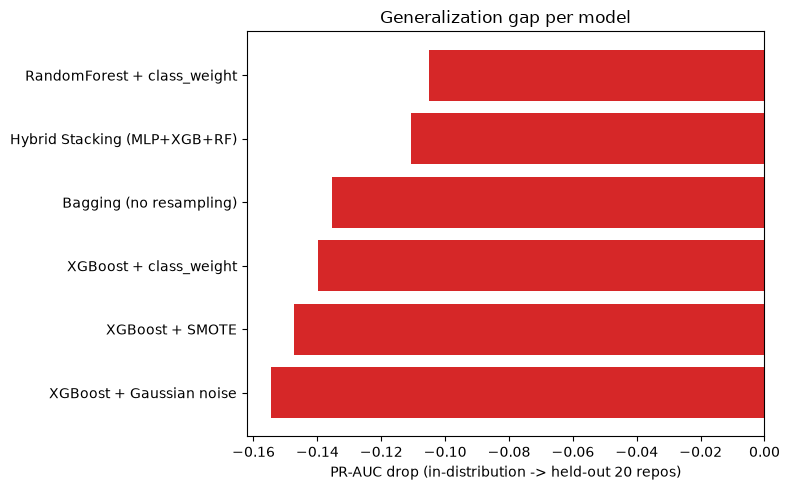

In [32]:
gap_df = pd.DataFrame({
    "in_distribution_pr_auc": results_df["pr_auc"],
    "holdout_pr_auc": holdout_df["pr_auc"],
})
gap_df["generalization_gap"] = gap_df["in_distribution_pr_auc"] - gap_df["holdout_pr_auc"]
gap_df = gap_df.sort_values("generalization_gap")
print(gap_df)

plt.figure(figsize=(8, 5))
plt.barh(gap_df.index, gap_df["generalization_gap"], color="#d62728")
plt.xlabel("PR-AUC drop (in-distribution -> held-out 20 repos)")
plt.title("Generalization gap per model")
plt.tight_layout()
plt.savefig("generalization_gap.png", dpi=150)
plt.show()


## Step 12 — Secondary experiment: do the extra 34 columns help? (Dataset B, 73-repo overlap only)

Same repo-grouped CV, restricted to the 73 overlapping repos, comparing the 44-metric-only
view against the full 78-column view. This never touches the 20-repo holdout.


In [35]:
feature_cols_B_44 = [c for c in shared_metric_cols if c in dataset_B.columns and c != "Vuln"]
feature_cols_B_full = [c for c in dataset_B.columns if c not in ["Vuln", "repo"]]
X_B = dataset_B[feature_cols_B_44].fillna(0).values
X_B_full = dataset_B[feature_cols_B_full].fillna(0).values
y_B = dataset_B["Vuln"].values
groups_B = dataset_B["repo"].values
mean_44, _, _ = run_baseline_cv(lambda y_tr, seed: make_xgb(y_tr, seed, use_class_weight=True), X_B, y_B, groups_B)
mean_78, _, _ = run_baseline_cv(lambda y_tr, seed: make_xgb(y_tr, seed, use_class_weight=True), X_B_full, y_B, groups_B)
print("XGBoost, 44 shared metrics only (73-repo overlap):")
print(mean_44.to_string())
print("\nXGBoost, all 78 columns (73-repo overlap):")
print(mean_78.to_string())
print(f"\nPR-AUC change from adding the 34 extra columns: {mean_78['pr_auc'] - mean_44['pr_auc']:+.4f}")


XGBoost, 44 shared metrics only (73-repo overlap):
accuracy     0.8179
precision    0.1784
recall       0.0889
f1           0.1161
pr_auc       0.1987
mcc          0.0342

XGBoost, all 78 columns (73-repo overlap):
accuracy     0.8061
precision    0.3219
recall       0.1280
f1           0.1764
pr_auc       0.3083
mcc          0.1059

PR-AUC change from adding the 34 extra columns: +0.1096


## Summary

- **In-distribution results** (`results_df`): how every model performs with repo-grouped CV on the 73-repo training pool — directly comparable to prior published numbers.
- **Holdout results** (`holdout_df`): the same models tested on 20 repos they've never seen at all.
- **Generalization gap** (`gap_df`): the actual new finding — which model holds up best moving from known to unseen code.
- **Dataset B comparison**: whether Viszkok's extra process/warning columns add anything on top of the shared 44 metrics.

Next steps beyond this notebook: write up the results into the final report, and optionally
wrap the best-performing model + a static-metric extractor into a small script that takes a
raw `.js` file and outputs a per-function risk score for a live demo.
